# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Joe Whibley
* Username: jcbwhibley
* Student number: 6411258
* Group (AS1, etc.): As6

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

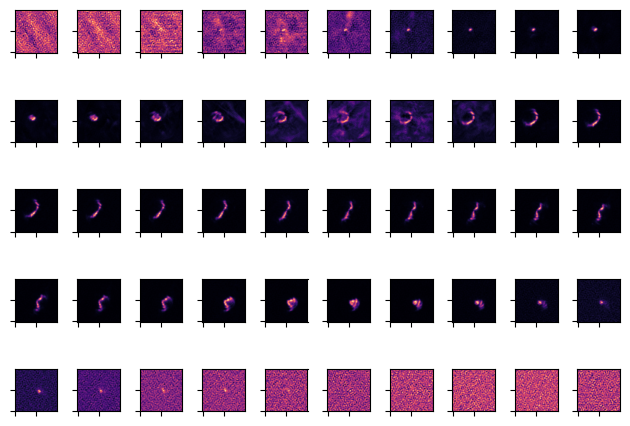

In [91]:
from astropy.io import fits
from matplotlib.pyplot import show, figure
import matplotlib.pyplot as plt
import numpy as np
from imageio import imwrite, imread

hdul = fits.open('ngc6946.fits')
data = hdul[0].data        #opening the data
hdr = hdul[0].header 


indices = list(range(1, 101, 2))  #creating a list of the indices for the data slice


fig, axes = plt.subplots(5, 10)    #creating the subplots
axes = axes.flatten()             #flattening the axes to iterate over


for i, idx in enumerate(indices):           #looping over the axes to graph the data
    ax = axes[i]                     #calls the ax to position the plot of data
    ax.imshow(data[idx,:,:], origin='lower', cmap='magma')       #plots the data (z indice, x everything, y everything)    magma cuz its pretty
    ax.set_xticklabels([])
    ax.set_yticklabels([])    #turns ticks off

    

plt.tight_layout()

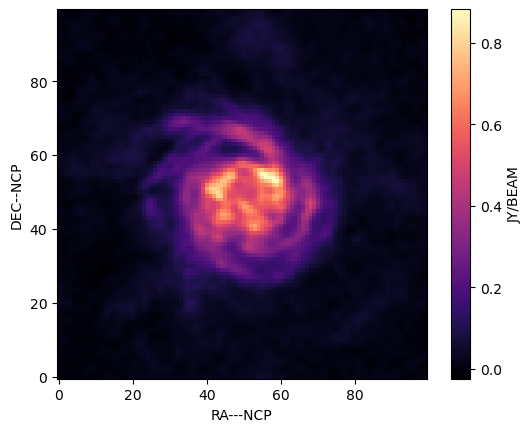

In [101]:
from astropy.io import fits
from matplotlib.pyplot import show, figure
import matplotlib.pyplot as plt
import numpy as np
from imageio import imwrite, imread

hdul = fits.open('ngc6946.fits')
data = hdul[0].data        #opening the data
hdr = hdul[0].header 

indices = list(range(7, 78, 2))
z_data = data[indices,:,:]

tot_HImap = np.sum(z_data, axis=0)       #sums the data along the z axis

plt.imshow(tot_HImap, origin='lower', cmap='magma')    #showing the image with lower origin
plt.xlabel(hdr['CTYPE1'])         #calling the hdr CTYPE1 and 2 for the axis labels
plt.ylabel(hdr['CTYPE2'])
plt.colorbar(label= hdr['BUNIT'])

plt.show()

Text(0, 0.5, 'VELO-HEL')

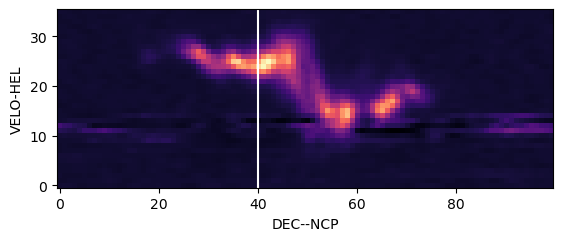

In [8]:
from astropy.io import fits
from matplotlib.pyplot import show, figure
import matplotlib.pyplot as plt
import numpy as np
from imageio import imwrite, imread

hdul = fits.open('ngc6946.fits')
data = hdul[0].data        #opening the data
hdr = hdul[0].header 

indices = list(range(7, 78, 2))
z_data = data[indices,:,:]

pv = z_data[:,:,50]



fig, ax = plt.subplots() 
ax.imshow(pv, origin='lower', cmap='magma') 
ax.axvline(x=40, color='w')
ax.set_xlabel(hdr['CTYPE2'])   
ax.set_ylabel(hdr['CTYPE3'])

Text(0, 0.5, 'JY/BEAM')

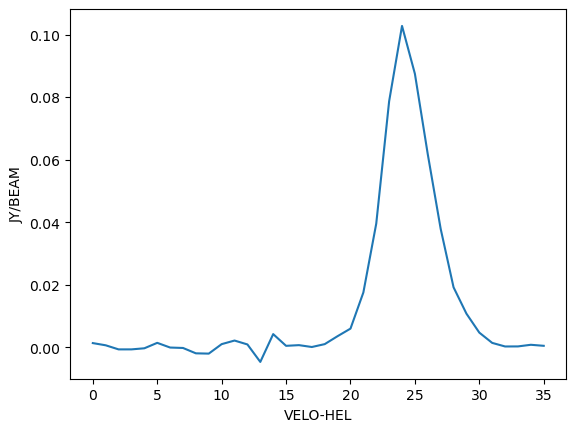

In [11]:
from astropy.io import fits
from matplotlib.pyplot import show, figure
import matplotlib.pyplot as plt
import numpy as np
from imageio import imwrite, imread

hdul = fits.open('ngc6946.fits')
data = hdul[0].data        #opening the data
hdr = hdul[0].header 

indices = list(range(7, 78, 2))
z_data = data[indices,:,:]     #taking the data in the range


Y = z_data[:,40,50]         #taking 1d intenisty slice 

fig, ax = plt.subplots() 

ax.plot(Y)
ax.set_xlabel(hdr['CTYPE3'])      #setting the axes label
ax.set_ylabel(hdr['BUNIT'])

 
#The spectral profile is a 1d profile of the intensity along the line in the last part

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

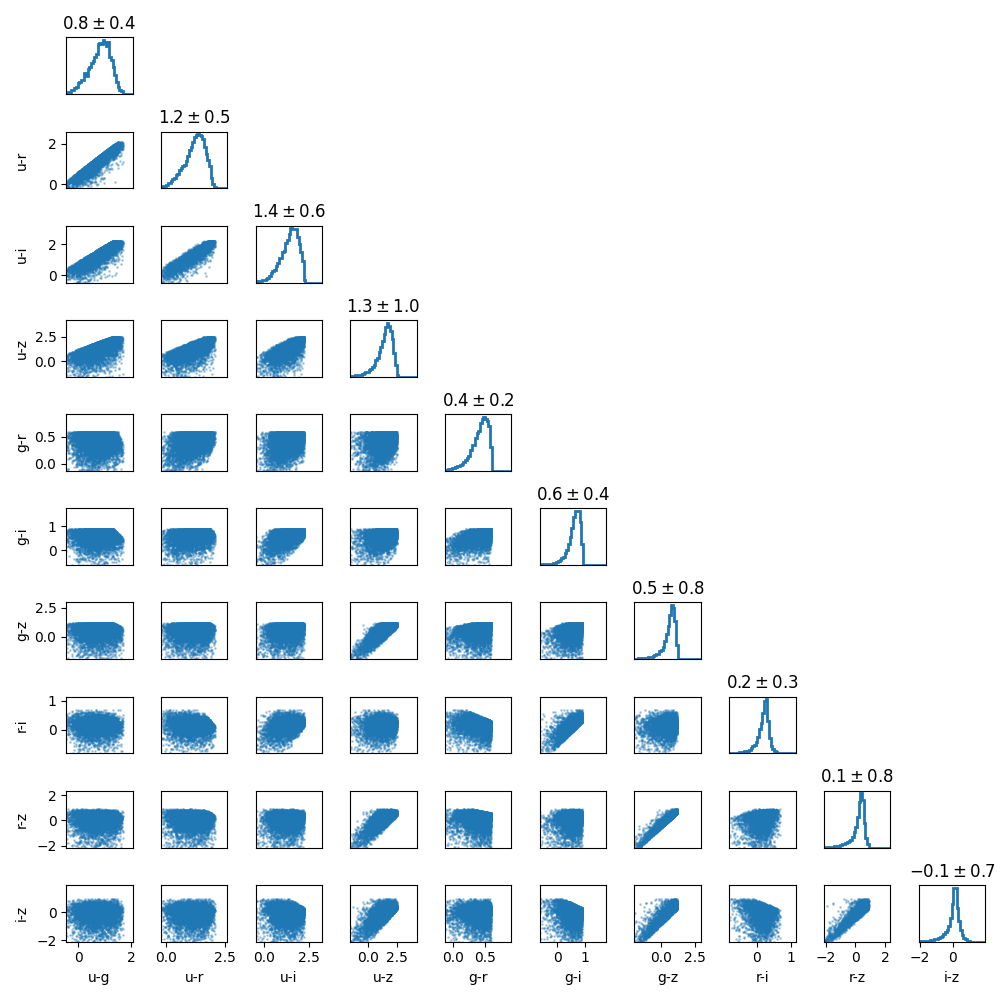
   
**Plot and answer**:

[] []


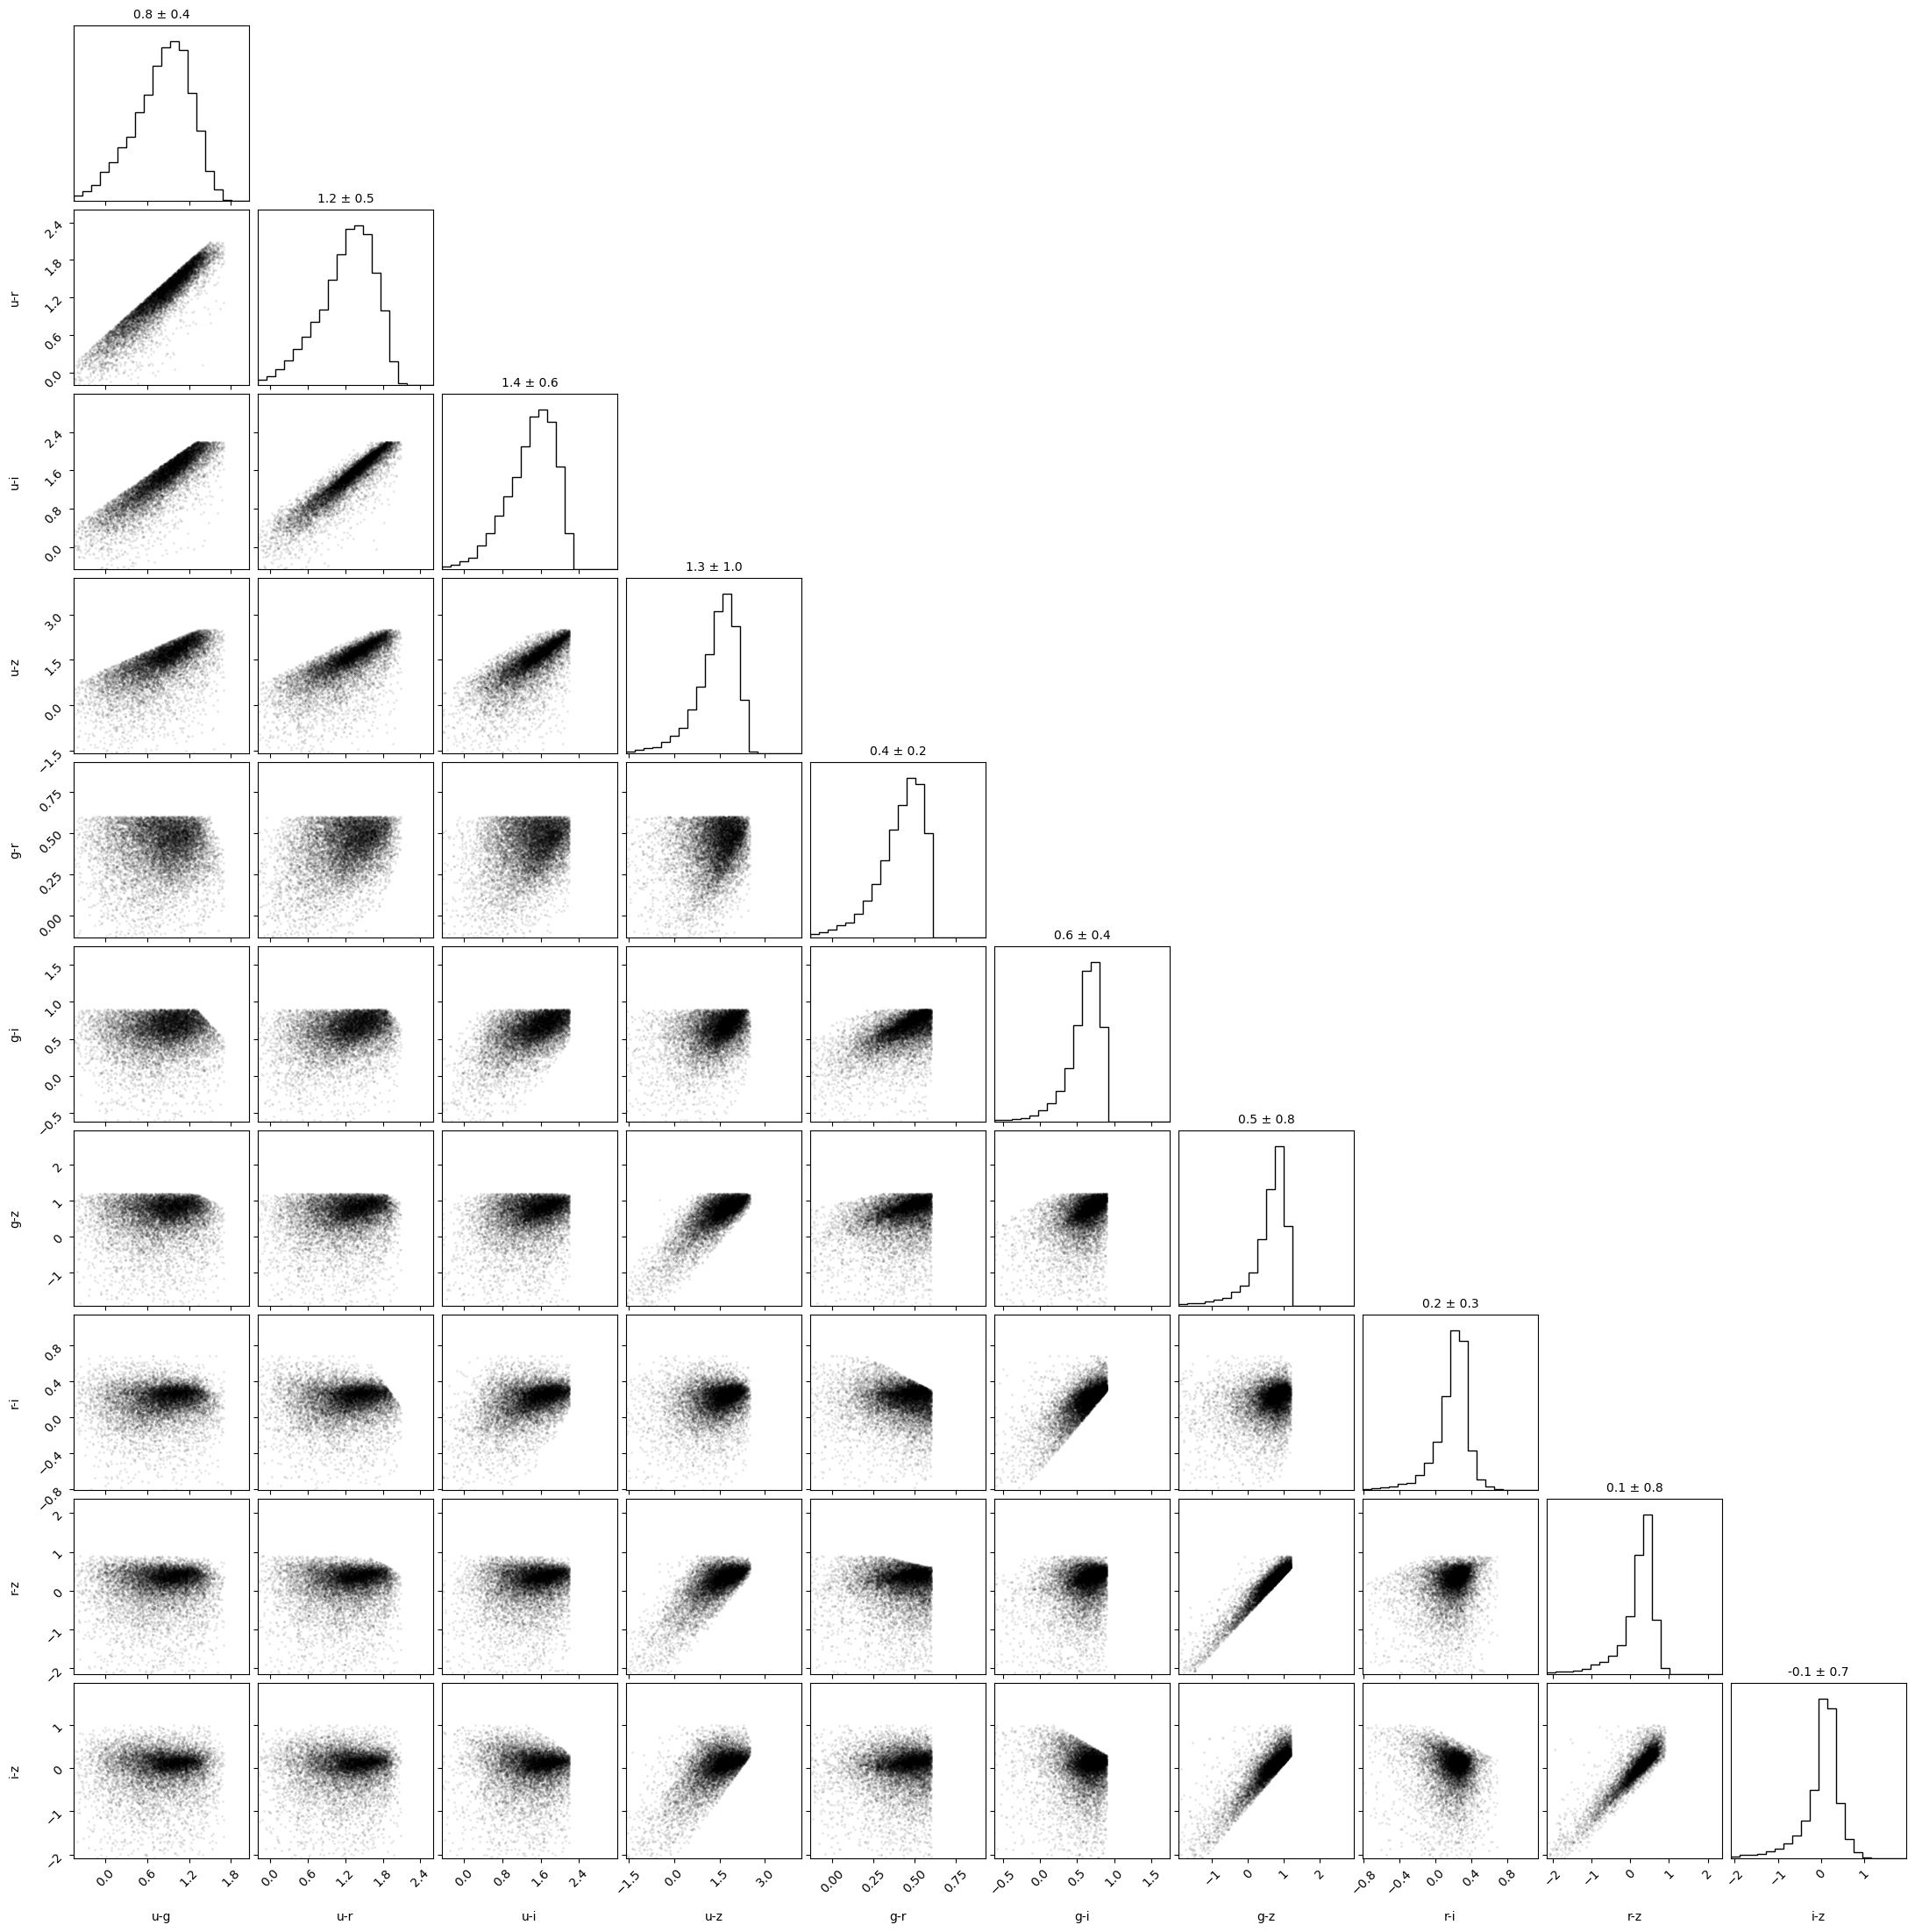

In [1]:
from astropy.io import fits
from matplotlib.pyplot import show, figure
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table
#!pip install corner
import corner

data = Table.read('SDSS_DR17_galaxies.fits', format='fits')
df = data.to_pandas()

df_clean =df[(df[['u', 'g', 'r', 'i', 'z']] >= 0).all(axis=1)]    #filtering out all negatives


cols = df[['u', 'g', 'r', 'i', 'z']]

ug = df_clean['u']-df_clean['g']
ur = df_clean['u']-df_clean['r']
ui = df_clean['u']-df_clean['i']
uz = df_clean['u']-df_clean['z']
gr = df_clean['g']-df_clean['r']
gi= df_clean['g']-df_clean['i']
gz= df_clean['g']-df_clean['z']
ri= df_clean['r']-df_clean['i']
rz= df_clean['r']-df_clean['z']
iz= df_clean['i']-df_clean['z']

colours = [ug,ur,ui,uz,gr,gi,gz,ri,rz,iz]

means_c=[]
stds_c = []

#for i in colours:
    #mean = np.mean(i)
   # std= np.std(i)
  #  means_c.append(mean)
  #  std_c.append(std)

print(means_c, stds_c)

color_data = {
    'u-g': ug, 'u-r': ur, 'u-i': ui, 'u-z': uz, 
    'g-r': gr, 'g-i': gi, 'g-z': gz, 
    'r-i': ri, 'r-z': rz, 'i-z': iz
}

# Convert to a DataFrame so corner knows the labels automatically
df_colors = pd.DataFrame(color_data)
#fig = corner.corner(df_colors)

# labels for your axes
labels = ['u-g', 'u-r', 'u-i', 'u-z', 'g-r', 'g-i', 'g-z', 'r-i', 'r-z', 'i-z']

# Calculate the (mean - 3*std, mean + 3*std) for each column
plot_ranges = []
for col in (labels):
    m = np.mean(df_colors[col])
    s = np.std(df_colors[col])  # using ordered list of stds
    stds_c.append(s)
    means_c.append(m)
    plot_ranges.append((m - 3*s, m + 3*s))

custom_titles = [f"{m:.1f} ± {s:.1f}" for m, s in zip(means_c, stds_c)]

fig = corner.corner(
    df_colors[labels], 
    labels=labels,
    range=plot_ranges,
    show_titles=True,
    plot_contours=False,    # Removes the contour lines
    plot_density=False,     # Removes the shaded background
    plot_datapoints=True,   # Shows the individual blue dots
)

axes = np.array(fig.axes).reshape((len(labels), len(labels)))

for i in range(len(labels)):
    # Grab the axis on the diagonal
    ax = axes[i, i]
    # Force custom string as the title
    ax.set_title(custom_titles[i], fontsize=10)

plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

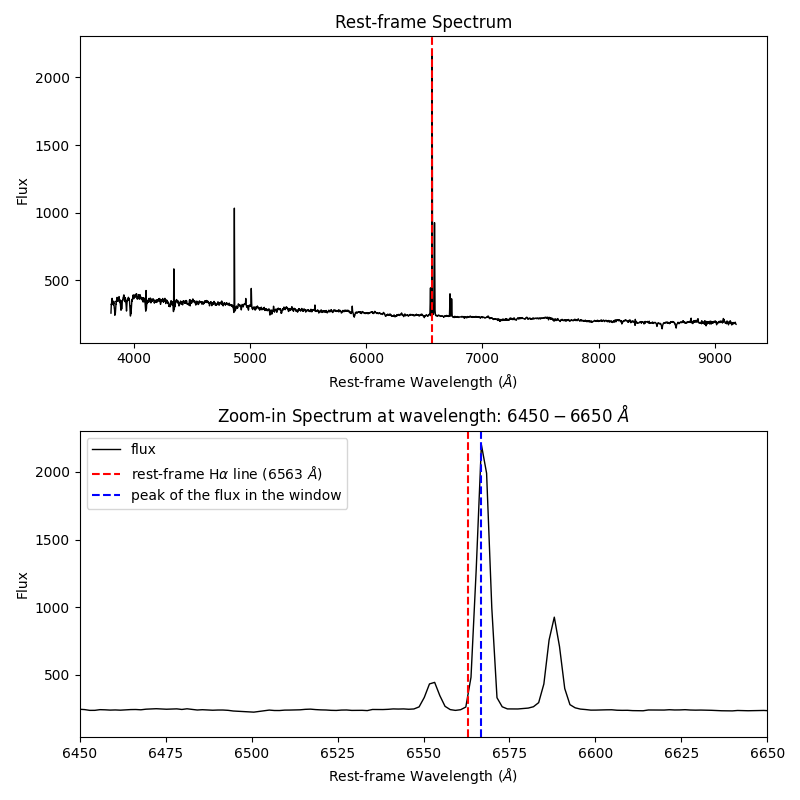

the velocity calculated from the shift in wavelengths is -169018.11644419233 km/s


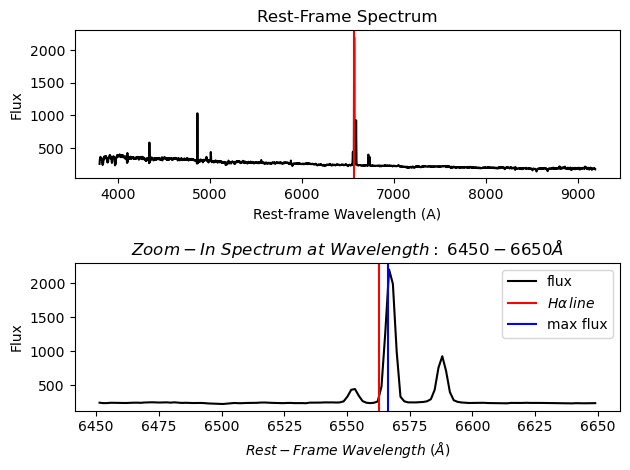

In [148]:
#!pip install astroquery
from astropy import coordinates as coords
from astropy import units as u
from astroquery.sdss import SDSS
import numpy as np
from matplotlib.pyplot import show, figure
import matplotlib.pyplot as plt
from scipy.constants import c


# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

radius = 10 * u.arcsec   #define search radius

spec_table = SDSS.query_region(pos, radius=radius, spectro=True)      #query w SSDS for spectra at that position,  pos = SkyCoord previously defined
hdul_list = SDSS.get_spectra(matches=spec_table)      #makes hdu list w get_spectra matches the query

hdu = hdul_list[0]   #calls first hdu thing
data=hdu[1].data    #turns hdu thing into data


flux = data['flux']      
wavelength = 10**(data['loglam'])     #turns log values to linear (inverse of the log base 10 eq)


z=0.0038     
lam_rest = wavelength/(1+z)     #calculating rest wavelength

w_min = 6450
w_max = 6650     #making a mask to take the right values (since indices dont work)
mask = (lam_rest >= w_min) & (lam_rest <= w_max)

lam_rest_zoom = lam_rest[mask]    #zoomed data
flux_zoom = flux[mask]

max_flux = 6566.5     #approximated max flux (by eye)

fig, ax = plt.subplots(2,1)
ax[0].plot(lam_rest, flux, color='black')                  #plotting the data
ax[0].set_title('Rest-Frame Spectrum')
ax[0].set_xlabel('Rest-frame Wavelength (A)')
ax[0].set_ylabel('Flux')



ax[1].plot(lam_rest_zoom, flux_zoom, color='black', label='flux')            #plotting the data
ax[1].set_title(rf'$Zoom-In\,\, Spectrum\,\, at \,\,Wavelength: \,\,6450 - 6650 \AA$')
ax[1].set_xlabel(rf'$Rest-Frame \,\, Wavelength\,\, (\AA)$')
ax[1].set_ylabel('Flux')

Halpha = 6562.8

ax[0].axvline(x=Halpha, color='r')
ax[1].axvline(x=Halpha, color='r', label=rf'$H \alpha \,line$')
ax[1].axvline(x=max_flux, color='b', label='max flux')          #adding lines


del_lam = Halpha-max_flux

v = c*(del_lam)/Halpha
print(f"the velocity calculated from the shift in wavelengths is {v} km/s")


plt.legend()
plt.tight_layout()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

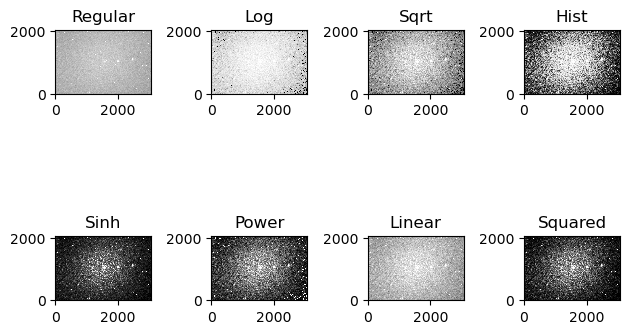

In [20]:
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
from astropy.io import fits
from matplotlib.pyplot import show, figure
import matplotlib.pyplot as plt
import numpy as np


image_data = fits.open('20210422_Li_.00000066.FIT')
data = np.array(image_data[0].data) 


def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):

    """Defining different scales and what they do"""
    
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)




fig, ax = plt.subplots(2,4)
imdisplay(data, ax[0,0], zscale=True)
imdisplay(data, ax[1,2], scale='linear')
imdisplay(data, ax[1,0], scale='sinh')
imdisplay(data, ax[0,1], scale='log')
imdisplay(data, ax[1,1], scale='power')
imdisplay(data, ax[0,2], scale='sqrt')
imdisplay(data, ax[1,3], scale='squared')
imdisplay(data, ax[0,3], scale='hist')


ax[0,0].set_title('Regular')
ax[1,2].set_title('Linear')
ax[1,0].set_title('Sinh')
ax[0,1].set_title('Log')
ax[1,1].set_title('Power')
ax[0,2].set_title('Sqrt')
ax[1,3].set_title('Squared')
ax[0,3].set_title('Hist')

fig.tight_layout()


show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [2]:
#!pip install astro
from pathlib import Path


datadir='Users/users/jcbwhibley/PROGNUM-repo/Task6'

path = Path(datadir)

excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are opart of the file name

filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

# Print first 5 file names
for f in filepaths[:5]:
    print(f.name)

FileNotFoundError: [Errno 2] No such file or directory: 'Users/users/jcbwhibley/PROGNUM-repo/Task6'

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")